# Linear Algebra Notes

I've wanted for a long time to learn basic linear algebra. I always hear people talk about how fundamental linear algebra is to, well, everything: statistics, computer science, machine learning, and so on—even in biology in the form of Leslie matrix models. I've personally taken a year-long sequence in graduate linear and multiple regression for psychology students, and I knew that we could not arrive at an intuitive understanding of the material because we didn't have the foundation in linear algebra.

My goal is, with a foundation in linear algebra, to understand statistics intuitively, and to be able to apply computational techniques to biology. I'll be using David Austin's [Understanding Linear Algebra](https://understandinglinearalgebra.org/) and Jim Hefferon's [Linear Algebra](https://hefferon.net/linearalgebra/) for the exercise sets, in addition to Khan Academy videos.

Perusing Reddit, I found that the topics I should cover are, in this order:

1. Span
2. Linear Independence
3. Basis
4. Dimension
5. Matrices
6. Linear Transformations
7. Eigenvalues and Eigenvectors

So I'll do my best covering these topics.

## Preliminaries

The term "linear algebra" sounds opaque and intimidating to me, but apparently, it really is just about *linear equations*. More specifically, Austin says, it is about "sets of two or more linear equations", which can number in the trillions in practice.

Sets of linear equations can have either:

* Infinitely many solutions,
* Exactly one solution, or
* No solution.

Here are some examples with two unknowns (variables):

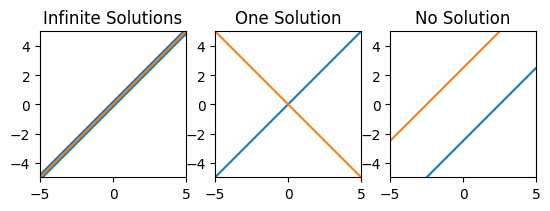

In [37]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

plt.subplot(1,3,1)
plt.plot(x,y,linewidth=4)
plt.plot(x,y)
plt.title("Infinite Solutions")
plt.axis("square")
plt.xlim(-5,5)
plt.ylim(-5,5)

plt.subplot(1,3,2)
plt.plot(x,y)
plt.plot(x,-y)
plt.title("One Solution")
plt.axis("square")
plt.xlim(-5,5)
plt.ylim(-5,5)

plt.subplot(1,3,3)
plt.plot(x,y-2.5)
plt.plot(x,y+2.5)
plt.title("No Solution")
plt.axis("square")
plt.xlim(-5,5)
plt.ylim(-5,5)

plt.show()

The general trend is that the more equations we have, the smaller the set of solutions, since:

* One equation has infinitely many solutions (**necessarily**),
* Two equations have exactly one solution (**unless the lines are parallel, as in the graphs above**), and
* Three equations have no solutions (**unless all lines intersect at the same point**).

These observations allow us to pose **two fundamental questions**: 
1. Does a solution **exist**?
2. If so, is the solution **unique**?

### Systems of linear equations

A **system of linear equation** is a set of equations with linear terms, and looks like this:

$$\begin{array}{rcl}
2x + 3y - 4z & = & 5 \\
-x + z & = & 10 \\
3x - 5y & = & -30
\end{array}
$$

And a **solution** is a set of numbers for the unknowns ($x$, $y$, and $z$ in this case) that satisfy all equations in the system. The **solution space** is the set of all solutions of the system.

### Gaussian elimination

To describe the solution space of a linear system, we need a reliable algorithm. **Gaussian elimination** does exactly this. Linear systems such as below is easily solved through **back substitution**:

$$\begin{array}{rcl}
x + 2y-2z & = & -4 \\
-y+z & = & 3 \\
3z & = & 3
\end{array}
$$

reduces to

$$\begin{array}{rcl}
x + 2y-2z & = & -4 \\
-y+z & = & 3 \\
z & = & 1
\end{array}
$$

reduces to

$$\begin{array}{rcl}
x + 2y & = & -2 \\
-y & = & 2 \\
\end{array}
$$

reduces to

$$\begin{array}{rcl}
x + 2y & = & -2 \\
y & = & -2 \\
\end{array}
$$

So the solution is $(2, -2, 1)$ (i.e. $x=2$, $y=-2$, and $z=1$).

Through three operations, **scaling**, **interchange**, and **replacement**, we can create a new system of equations from an old system of equations with the same solution space.

### Augmented matrices

Given the following system of linear equations:

$$\begin{array}{rcl}
x + 2y-2z & = & -4 \\
-y+z & = & 3 \\
3z & = & 3
\end{array}
$$

The **coefficient matrix** is:
$$
\begin{equation*}
\left[
\begin{array}{rrr}
1 & 2 & -2 \\
0 & -1 & 1 \\
0 & 0 & 3 \\
\end{array}
\right]
\end{equation*}
$$

And the **augmented matrix** is:

$$
\begin{equation*}
\left[
\begin{array}{rrr|r}
1 & 2 & -2 & -4\\
0 & -1 & 1 & 3\\
0 & 0 & 3 & 1\\
\end{array}
\right]
\end{equation*}
$$

**Row equivalent** matrices are derivable through scaling, interchange, and replacement from one another. Because they are, in essence, the same matrix, they have the same solution space. We use a tilde ($\sim$) to denote row equivalence. 

$$
\begin{equation*}
\left[
\begin{array}{rrr|r}
1 & 2 & -2 & -4\\
0 & -1 & 1 & 3\\
0 & 0 & 3 & 1\\
\end{array}
\right]
\sim
\left[
\begin{array}{rrr|r}
1 & 0 & 0 & 2\\
0 & 1 & 0 & -2\\
0 & 0 & 1 & 1\\
\end{array}
\right]
\end{equation*}
$$

### Reduced row echelon form

The following matrix is said to be in **reduced row echelon form** (RREF). 

$$
\begin{equation*}
\left[
\begin{array}{rrr|r}
1 & 0 & 0 & 2\\
0 & 1 & 0 & -2\\
0 & 0 & 1 & 1\\
\end{array}
\right]
\end{equation*}
$$

The criteria are:
* If the entries in a row are all 0, then the same is true of any row below the row.
* The leading entry in each row must be 1.
* A leading entry must be left of any leading entry in all rows below.
* A leading entry must be the only nonzero entry in its **column**.

**Theorem**. There is exactly one RREF for any given matrix.

**Augmentation Principle**. If matrix $B$ is an augmentation of matrix $A$, then the RREF of $B$ is an augmentation of the RREF of $A$. So, if:

$$
\begin{equation*}
\left[
\begin{array}{ccc}
-2 & 3 & 0 \\
-1 & 4 & 1 \\
3 & 0 & 2 \\
1 & 5 & 3 \\
\end{array}
\right]
\sim
\left[
\begin{array}{ccc}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1 \\
0 & 0 & 0 \\
\end{array}
\right]
\end{equation*}
$$

Then the augmented form is:

$$
\begin{equation*}
\left[
\begin{array}{ccc|c}
-2 & 3 & 0 & 2 \\
-1 & 4 & 1 & 3 \\
3 & 0 & 2 & 2 \\
1 & 5 & 3 & 7 \\
\end{array}
\right]
\sim
\left[
\begin{array}{ccc|c}
1 & 0 & 0 & -4 \\
0 & 1 & 0 & -2 \\
0 & 0 & 1 & 7 \\
0 & 0 & 0 & 0 \\
\end{array}
\right]
\end{equation*}
$$

### Pivot position

A **pivot position** is the position of a leading entry in a reduced row echelon matrix They are indicated in bold below:

$$
\begin{equation*}
\begin{bmatrix}
{\mathbf 1} & 0 & * & 0 \\
0 & {\mathbf 1} & * & 0 \\
0 & 0 & 0 & {\mathbf 1} \\
0 & 0 & 0 & 0 \\
\end{bmatrix}
\end{equation*}
$$

The position and number of pivot positions can help us answer the **fundamental questions**.

#### Existence

A linear system is inconsistent, meaning that there is no solution, **if and only if** there is a pivot position in the last column of an augmented matrix. So the below matrix corresponds to an inconsistent linear system:

$$
\begin{equation*}
\left[
\begin{array}{rrr|r}
1 & * & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0 \\
\end{array}
\right]\text{.}
\end{equation*}
$$

This makes sense, because the row $(0, 0, 0, 1)$ indicates that $0x+0y+0z = 1$, which cannot be true.

On the flip side, if every row of the coefficient matrix has a pivot position, then the corresponding linear system is consistent. So the below matrix corresponds to a consistent linear system, meaning there must be at least one solution:

$$
\begin{equation*}
\left[
\begin{array}{ccc}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1 \\
\end{array}
\right]
\end{equation*}
$$

This matrix in particular tells us that there is exactly one solution, as we will see.

#### Uniqueness

Given a consistent linear system, if **every column** in the coefficient matrix contains a **pivot position**, then the system has a **unique** solution. So visiting again the matrix:

$$
\begin{equation*}
\left[
\begin{array}{ccc}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1 \\
\end{array}
\right]
\end{equation*}
$$

We know that there is a unique value for $(x,y,z)$ (in the augmented column) that satisfies the corresponding linear system.

On the other hand, if there is **a column** in the coefficient matrix that contains **no pivot position**, then the system has **infinitely many** solutions. So, given the augmented matrix with with no pivot in the coefficient column for $z$:

$$
\begin{equation*}
\left[
\begin{array}{rrr|r}
1 & 0 & 2 & -2 \\
0 & 1 & 1 & 4 \\
0 & 0 & 0 & 0 \\
\end{array}
\right]
\end{equation*}
$$

We obtain the solution:

$$\begin{array}{rcl}
x & = & -2-2z \\
y & = & 4-z
\end{array}
$$

So we have infinitely many solutions.

Columns that contain a pivot position correspond to **basic variables**, which can be solved for, whereas columns that do not contain a pivot position correspond to **free variables**. The choice of basic vs. free variables can be somewhat arbitrary, and we are interested more in the number of free variables, as we will see in the future.

### Linear combinations

The **linear combination** of vectors is the sum of vectors, each scaled by a constant factor, in the form $c\vec{v}+d\vec{w}$. For example, the following is a linear combination:
$$12\vec{a} + -2\vec{b}$$

The scalars $c_1, c_2, \dots, c_n$ are called the **weights** of the linear combination.

Given a vector $\vec{b}$, asking whether $\vec{b}$ is a linear combination of vectors $\vec{v_1}, \vec{v_2}, \dots, \vec{v_n}$ is equivalent to asking whether the corresponding linear system is consistent. Given that:
$$
\begin{equation*}
\vec{v_1} = \left[\begin{array}{r} 4 \\ 0 \\ 2 \\ 1
\end{array} \right], 
\vec{v_2} = \left[\begin{array}{r} 1 \\ -3 \\ 3 \\ 1
\end{array} \right], 
\vec{v_3} = \left[\begin{array}{r} -2 \\ 1 \\ 1 \\ 0
\end{array} \right], 
\vec{b}   = \left[\begin{array}{r} 0 \\ 1 \\ 2 \\ -2
\end{array} \right]\text{,}
\end{equation*}
$$

We evaluate:

In [36]:
from sympy import Matrix
m = Matrix(4,4,[4,1,-2,0,0,-3,1,1,2,3,1,2,1,1,0,-2])
m.rref()

(Matrix([
 [1, 0, 0, 0],
 [0, 1, 0, 0],
 [0, 0, 1, 0],
 [0, 0, 0, 1]]),
 (0, 1, 2, 3))

And find the row $(0, 0, 0, 1)$, which tells us that the corresponding linear system is **not** consistent. That means that $\vec{b}$ is not a linear combination of $\vec{v_1}, \vec{v_2}$ and $\vec{v_3}$. 

**Matrix-vector multiplication** can be thought of as a linear combination. Given:
$$
\begin{equation*}
A = \left[\begin{array}{rr}
-2 & 3 \\
0 & 2 \\
3 & 1 \\
\end{array}\right],~~~
\vec{x} = \left[\begin{array}{r}
2 \\ 3 \\ \end{array}\right]\text{.}
\end{equation*}
$$

We use $\vec{x}$ as the weights:
$$
\begin{equation*}
\begin{aligned}
A\vec{x} = 
\left[\begin{array}{rr}
-2 & 3 \\
0 & 2 \\
3 & 1 \\
\end{array}\right]
\left[\begin{array}{r} 2 \\ 3 \\ \end{array}\right]
{}={} &
2 \left[\begin{array}{r} -2 \\ 0 \\ 3 \\ \end{array}\right] +
3 \left[\begin{array}{r} 3 \\ 2 \\ 1 \\ \end{array}\right]
\\ \\
{}={} &
\left[\begin{array}{r} -4 \\ 0 \\ 6 \\ \end{array}\right] +
\left[\begin{array}{r} 9 \\ 6 \\ 3 \\ \end{array}\right] \\ \\
{}={} &
\left[\begin{array}{r} 5 \\ 6 \\ 9 \\ \end{array}\right]. \\
\end{aligned}
\end{equation*}
$$

The equation $A\vec{x} = \vec{b}$ is a notationally compact way to write a linear system. Given:


$$
\begin{equation*}
\left[\begin{array}{rrr}
2 & 0 & 2 \\
4 & -1 & 6 \\
1 & 3 & -5 \\
\end{array}\right]
\vec{x}
=
\left[\begin{array}{r}
0 \\ -5 \\ 15
\end{array}\right]
\end{equation*}
$$

We derive the RREF:
$$
\begin{equation*}
\left[\begin{array}{rrr|r}
2 & 0 & 2 & 0 \\
4 & -1 & 6 & -5 \\
1 & 3 & -5 & 15 \\
\end{array} \right]
\sim
\left[\begin{array}{rrr|r}
1 & 0 & 1 & 0 \\
0 & 1 & -2 & 5 \\
0 & 0 & 0 & 0 \\
\end{array} \right],
\end{equation*}
$$

Which corresponds to the linear system:
$$
\begin{equation*}
\begin{alignedat}{4}
x_1 & & & {}+{} & x_3 & {}={} & 0 \\
& & x_2 & {}-{} & 2x_3 & {}={} & 5 \\
\end{alignedat}
\end{equation*}
$$

And because $x_3$ is free, we can write the parametric solution space:

$$
\begin{equation*}
\begin{aligned}
x_1 & {}={} -x_3 \\
x_2 & {}={} 5+2x_3 \\
\end{aligned}
\end{equation*}
$$

Which gives us, as $\vec{x}$,

$$
\begin{equation*}
\vec{x}
=\left[
\begin{array}{r}
x_1 \\ x_2 \\ x_3
\end{array}
\right]
=
\left[
\begin{array}{r}
-x_3 \\ 5 + 2x_3 \\ x_3
\end{array}
\right]
=\left[\begin{array}{r}0\\5\\0\end{array}\right]
+x_3\left[\begin{array}{r}-1\\2\\1\end{array}\right]
\end{equation*}
$$

**Matrix-matrix multiplication** can be thought of as matrix-vector multiplication, by taking apart the second matrix into individual vectors. So, given:
$$
\begin{equation*}
A = \left[\begin{array}{rr}
4 & 2 \\
0 & 1 \\
-3 & 4 \\
2 & 0 \\
\end{array}\right],~~~
B = \left[\begin{array}{rrr}
-2 & 3 & 0 \\
1 & 2 & -2 \\
\end{array}\right]\text{,}
\end{equation*}
$$

We take apart $B$ into component vectors, and do matrix-vector multiplication:
$$
\begin{equation*}
AB = \left[\begin{array}{rrr}
A \left[\begin{array}{r}
-2 \\ 1\end{array}\right] &
A \left[\begin{array}{r}
3 \\ 2\end{array}\right] &
A \left[\begin{array}{r}
0 \\ -2\end{array}\right]
\end{array}\right]
= \left[\begin{array}{rrr}
-6 & 16 & -4 \\
1 & 2 & -2 \\
10 & -1 & -8 \\
-4 & 6 & 0
\end{array}\right]\text{.}
\end{equation*}
$$

Each column in the final matrix corresponds to $A$ multiplied by a component vector of $B$.

Now that we are comfortable with the matrix multiplication, we can reformulate the **two fundamental questions** as follows:
* **Existence**: Is there a solution to the equation $A\vec{x} = \vec{b}$?
* **Uniqueness**: If there is a solution to $A\vec{x} = \vec{b}$, is it unique?

## Span

The **span** of a set of vectors $\vec{v_1}, \vec{v_2}, \dots, \vec{v_3}$ is all vectors $\vec{b}$ such that, if $A = [\vec{v_1} \vec{v_2} \dots \vec{v_3}]$, then $A\vec{x} =\vec{b}$ is consistent. In other words, the span is the set of all linear combinations of $\vec{v_1}, \vec{v_2}, \dots, \vec{v_3}$.

For example, given vectors:

$$\vec{v} = \begin{bmatrix}
-2\\
1
\end{bmatrix} \text{ and } \vec{w} = \begin{bmatrix}
8\\
-4
\end{bmatrix},$$

The following vector $\vec{b}$ is one vector in the span of $\vec{v}$ and $\vec{w}$.

$$
\begin{equation*}
\vec{b} = 3\vec{v} + \vec{w} = \begin{bmatrix}
2\\
-1
\end{bmatrix}
\end{equation*}
$$

In the opposite direction, we can check whether $\vec{b}=\begin{bmatrix}
5\\
2
\end{bmatrix}$ is in the span of $\vec{v}$ and $\vec{w}$:

$$
\begin{equation*}
\left[
\begin{array}{rr|r}
-2 & 8 & 5 \\
1 & -4 & 2 \\
\end{array}
\right]
\sim
\left[
\begin{array}{rr|r}
1 & -4 & 0 \\
0 & 0 & 1 \\
\end{array}
\right],
\end{equation*}
$$

The row $(0,0,1)$ shows that the equation $A\vec{x}=\vec{b}$ is inconsistent. So $\vec{b}$ is not in the span of $\vec{v}$ and $\vec{w}$.

Geometrically, the span consists of all the points we can walk to following a linear combination of the vectors. So:

* $n$ **non-collinear** vectors of **magnitude greater than zero** has a span that covers the space of real numbers in $\mathbb{R}^n$. So 3 non-collinear vectors that have a length > 0 have the entirety of the 3-dimensional number space ($\mathbb{R}^3$) as the span.
* $n$ collinear vectors have only a line as the span.
* A vector of magnitude zero has a span consisting only of point $(0,0)$.

Given two non-collinear vectors $\vec{v}=\begin{bmatrix}
2\\
0
\end{bmatrix}$ and $\vec{w}=\begin{bmatrix}
-1\\
1
\end{bmatrix}$, we can construct the coefficient matrix which has a pivot position in every row:
$$
\begin{equation*}
\begin{bmatrix}
2 & -1 \\
0 & 1 \\
\end{bmatrix}
\sim
\begin{bmatrix}
1 & 0 \\
0 & 1 \\
\end{bmatrix}
\end{equation*}
$$

This means that there necessarily cannot be a pivot position in the augmented column, and therefore every value of the 2-dimensional vector $\vec{b}$ must be consistent with the vectors $\vec{v}$ and $\vec{w}$. In other words, **any vector $\vec{b}$ in $\mathbb{R}^2$ can be created with a linear combination of $\vec{v}$ and $\vec{w}$.**

### Pivot positions and span

Supposing that we are in $\mathbb{R}^3$, a single vector in $A$ will yield a single pivot position, and its span will a line. 
$$
\begin{equation*}
\begin{bmatrix}
-2 \\
3 \\
1
\end{bmatrix}
\sim
\begin{bmatrix}
1 \\
0 \\
0
\end{bmatrix}
\end{equation*}
$$

Two non-collinear vectors in $A$ will yield two pivot positions, and its span will be a plane:
$$
\begin{equation*}
\left[\begin{array}{rr}
-2 & 1 \\
3 & -1 \\
1 & 3 \\
\end{array}\right]
\sim
\left[\begin{array}{rr}
1 & 0 \\
0 & 1 \\
0 & 0 \\
\end{array}\right]
\end{equation*}
$$

Three non-collinear vectors in $A$ will yield three pivot positions. Because there cannot possibly be a pivot position in the augmented column, any linear system $A\vec{x} = \vec{b}$ must be consistent, and $\text{Span}(A) = \mathbb{R}^3$.
$$
\begin{equation*}
\left[\begin{array}{rrr|r}
1 & 2 & -2 & *\\
2 & 0 & 2 & * \\
-1 & 1 & 0 & * \\
\end{array}\right]
\sim
\left[\begin{array}{rrr|r}
1 & 0 & 0 & *\\
0 & 1 & 0 & * \\
0 & 0 & 1 & * \\
\end{array}\right]
\end{equation*}
$$

In other words, three non-collinear vectors in a linear combination can reach every point in a 3-dimensional space. 

**Proposition**. Suppose that we have vectors $\vec{v_1}, \vec{v_2}, \dots, \vec{v_n} \in \mathbb{R}^m$. Then, $\text{Span}(\{\vec{v_1}, \vec{v_2}, \dots, \vec{v_n}\}) = \mathbb{R}^m$ if and only if matrix $[\vec{v_1} \space \vec{v_2} \space \dots \space \vec{v_n}]$ has a pivot position in every row. 

**Proposition**. A set of vectors whose span is $\mathbb{R}^m$ contains at least $m$ vectors.

**Terminology**. Span is connected to sets of vectors, not matrices. We say "the span of the set of vectors $\vec{v_1}, \vec{v_2}, \dots, \vec{v_n}$", or "the span of the columns of matrix $A$", not "the span of matrix $A$".

## Linear independence

A set of vectors is **linearly independent** if and only if the vectors cannot be reduced to a single vector. That is, the vector adds a new dimension that the set of vectors can access. For example, if:

$$\vec{a} = \begin{bmatrix}
1\\
3
\end{bmatrix}$$

and 

$$\vec{b} = \begin{bmatrix}
2\\
6
\end{bmatrix}$$

The vectors $\vec{a}$ and $\vec{b}$ are collinear. In fact, $\vec{b}$ can be represented as $2\vec{a}$. Then, a linear combination of $\vec{a}$ and $\vec{b}$ does not allow access to the two-dimensional space, and $\vec{b}$ is **not** linearly independent of $\vec{a}$, and set $\{\vec{a}, \vec{b}\}$ is linearly dependent.

More rigorously, the set of vectors

$$s = \{v_1, v_2, \dots, v_n\}$$

is linearly independent if and only if the only way to satisfy the equation

$$c_1v_1 + c_2v_2 + \dots + c_nv_n = \vec{0}$$

Where $\vec{0}$ is a vector consisting of only zeros, is to make every coefficient $c_i = 0$.

**Example**. Is the following set linearly independent?

$$\{\begin{bmatrix}
2 \\
1
\end{bmatrix},
\begin{bmatrix}
3 \\
2
\end{bmatrix}
\}$$

**Solution**. Yes. $c_1$ and $c_2$ both must equal 0 in order to yield $\vec{0}$. More specifically,

$$2c_1 + 3c_2 = 0$$
$$c_1+2c_2=0$$

Solving this system of equations yields $c_1 = 0$ and $c_2 = 0$.

**Example**. Is the following set linearly independent?

$$\{\begin{bmatrix}
2 \\
1
\end{bmatrix},
\begin{bmatrix}
3 \\
2
\end{bmatrix},
\begin{bmatrix}
1 \\
2
\end{bmatrix}
\}$$

**Solution**. 

$$2c_1 + 3c_2 + c_3 = 0$$
$$c_1 + 2c_2 + 2c_3 = 0$$

Pick any arbitrary number for $c_3$. Supposing $c_3 = 10$, $c_1 = 40$ and $c_2 = -30$. There exists a solution for this system of equations where every $c_i$ does not equal 0, so this set is linearly dependent.

In [1]:
import numpy as np

In [3]:
a = np.array([3, 4, 5])
b = np.array([1, 3, 6])

A **dot product** is defined as follows:

$$\vec{a}\cdot\vec{b} = ||\vec{a}|| \space ||\vec{b}|| \cos(\theta)$$

Broken down, we are combining the magnitudes of vectors $\vec{a}$ and $\vec{b}$ on the basis of the angle between them. 

* When $\theta = 0$ (the vectors point in the exact same direction), the dot product is greatest, because $\cos(\theta) = 1$.
* When $\theta = \pi/2$ (the vectors are perpendicular), the dot product equals zero, because $\cos(\pi/2) = 0$.
* When $\pi/2 < \theta < 3\pi/2$ (the vectors are pointing in opposed directions), the dot product is negative.

It turns out that computing the dot product is quite easy, and need not involve any trigonometry:
$$\vec{a} = (a_1, a_2, a_3)$$

$$\vec{b} = (b_1, b_2, b_3)$$

$$\vec{a}\cdot\vec{b} = a_1b_1 + a_2b_2 + c_3b_3$$

I do not know why the geometric and algebraic definitions are equivalent, and I hope to understand at some point in my life.

In [4]:
np.dot(a,b)

45

A **cross product** is defined as follows:

$$\vec{a} \times \vec{b} = ||\vec{a}|| \space ||\vec{b}|| \sin(\theta) \space \vec{u} $$

where $\vec{u}$ is a unit vector perpendicular to the plane containing $\vec{a}$ and $\vec{b}$ such that $(\vec{a}, \vec{b}, \vec{u})$ is positively oriented. That is, we want the cross product to be in the orientation of the thumb when we make this silly looking gesture with our right hand:

![The right hand rule for the cross produtc](righthandrule.svg)

The cross product has two special properties:

1. The cross product is perpendicular to both $\vec{a}$ and $\vec{b}$. This is why the cross product only works in three dimensions.
2. The cross product measures how far apart $\vec{a}$ and $\vec{b}$ are measuring.

The cross product can be calculated algebraically, but it really sucks.

$$\vec{a} = (a_1, a_2, a_3)$$

$$\vec{b} = (b_1, b_2, b_3)$$

$$\vec{a} \times \vec{b} = \begin{bmatrix}
a_2b_3 - a_3b_2\\
a_3b_1 - a_1b_3\\
a_1b_2 - a_2b_1
\end{bmatrix}$$

In [5]:
np.cross(a,b)

array([  9, -13,   5])

Because the cross product is perpendicular to both $\vec{a}$ and $\vec{b}$, taking the dot product of either $\vec{a}$ or $\vec{b}$ with $\vec{a}\times\vec{b}$ will yield 0.

In sum:

1. The dot product returns a number, but the cross product returns a vector.
2. The dot product works in any number of dimensions, but the cross product only works in three dimensions.
3. The dot product measures how much two vectors point in the same dimension, but the cross product measures how much two vectors point in different directions.

In Python, we can create matrices quite easily:

In [10]:
x = np.matrix([[1,2,3],[4,5,6]])
x

matrix([[1, 2, 3],
        [4, 5, 6]])

We can check the dimensions like so:

In [11]:
x.shape

(2, 3)

To **multiply** two matrices, the number of columns of the first matrix must equal the number of rows in the second matrix. We multiply such that the first element in the column of the first matrix multiplies with the first element in the row of the second matrix and so on, and then we sum it all.

$$
\begin{bmatrix}
0 & 1 \\
2 & 3
\end{bmatrix}
\begin{bmatrix}
4 & 5 \\
6 & 7
\end{bmatrix}
=
\begin{bmatrix}
0 \cdot 4 + 1 \cdot 6 & 0 \cdot 5 + 1 \cdot 7 \\
2 \cdot 4 + 3 \cdot 6 & 2 \cdot 5 + 3 \cdot 7
\end{bmatrix}
=
\begin{bmatrix}
6 & 7 \\
26 & 31
\end{bmatrix}
$$

The dimensions of the product matrix will always be the number of rows in A and the number of columns in B. A $1 \times 2$ matrix and a $2 \times 1$ matrix will produce a $1 \times 1$ matrix:

$$
\begin{bmatrix}
0 & 1
\end{bmatrix}
\begin{bmatrix}
2 \\
3
\end{bmatrix}
=
\begin{bmatrix}
0 \cdot 2 + 1 \cdot 3
\end{bmatrix}
=
\begin{bmatrix}
3
\end{bmatrix}
$$

In [14]:
a = np.matrix([[1,2,3],[4,5,6],[7,8,9]])
b = np.matrix([[11,12,13],[14,15,16],[17,18,19]])
c = np.matrix([[21],[22],[23]])

In [15]:
a*c

matrix([[134],
        [332],
        [530]])

A **transpose** of a matrix switches the rows and the column, such that each entry $a_{i,j}$ becomes $a_{j,i}$. For example, given:

$$
A = \begin{bmatrix}
3 & -2 & 5\\
4 & 2 & 1
\end{bmatrix}
$$

The transpose is:

$$
A^T = \begin{bmatrix}
3 & 4 \\
-2 & 2\\
5 & 1
\end{bmatrix}
$$

In [16]:
np.transpose(c)

matrix([[21, 22, 23]])

A **determinant** represents how much a matrix stretches or squeezes space. Given unit vectors in two dimensions, the area of the square demarcated by the unit vectors is 1. 

* If the determinant is greater than 1, the matrix stretches the space.
* If the determinant equals 1, the matrix does not stretch or squeeze the space. An example would be rotation.
* If the determinant is less than 1, the matrix squeezes the space.
* If the determinant is equal to 0, the matrix squeezes the space such that the unit vectors now lie on the same line.
* If the determinant is less than 0, the matrix flips orientations.

For a **two-dimensional matrix**, the formula for the determinant is:

$$\det(\begin{bmatrix}
a & b \\
c & d\end{bmatrix}) = ad-bc$$.

For example:

$$\det(\begin{bmatrix}
1 & 3\\
5 & 4
\end{bmatrix}) = 1 \cdot 4 - 3 \cdot 5 = -11$$

So this matrix flips the orientations of the space.

For a **three-dimensional matrix**, it is a much greater PITA.

$$\det(\begin{bmatrix}
a & b & c\\
d & e & f\\
g & h & i
\end{bmatrix}) = a \space \det(\begin{bmatrix}e & f \\ h & i\end{bmatrix}) - b \space \det(\begin{bmatrix}d & f \\ g & i\end{bmatrix}) + c \space \det(\begin{bmatrix}d & e \\ g & h\end{bmatrix}) $$.

The **cross product** of two vectors $\vec{a}$ and $\vec{b}$ is actually the determinant of the three-dimensional vector:

$$\det(\begin{bmatrix}
\vec{i} & \vec{j} & \vec{k}\\
a_1 & a_2 & a_3\\
b_1 & b_2 & b_3
\end{bmatrix})$$

Where the first row consists of the unit vectors.

The **linear combination** of vectors is the sum of vectors, each scaled by a constant factor. For example,
$$12\vec{a} + -2\vec{b}$$
is a linear combination. It is the case that a linear combination of:
* two non-collinear vectors of magnitude greater than zero has a **span** that covers the space of real numbers in two dimensions.
* two collinear vectors has a span that only covers a line.
* a vector of magnitude zero has a span that only covers the point (0,0).

A set of vectors is **linearly independent** if and only if the vectors cannot be reduced to a single vector. That is, the vector adds a new dimension that the set of vectors can access. For example, if:

$$\vec{a} = \begin{bmatrix}
1\\
3
\end{bmatrix}$$

and 

$$\vec{b} = \begin{bmatrix}
2\\
6
\end{bmatrix}$$

The vectors $\vec{a}$ and $\vec{b}$ are collinear. In fact, $\vec{b}$ can be represented as $2\vec{a}$. Then, a linear combination of $\vec{a}$ and $\vec{b}$ does not allow access to the two-dimensional space, and $\vec{b}$ is **not** linearly independent of $\vec{a}$, and set $\{\vec{a}, \vec{b}\}$ is linearly dependent.

More rigorously, the set of vectors

$$s = \{v_1, v_2, \dots, v_n\}$$

is linearly independent if and only if the only way to satisfy the equation

$$c_1v_1 + c_2v_2 + \dots + c_nv_n = \vec{0}$$

Where $\vec{0}$ is a vector consisting of only zeros, is to make every coefficient $c_i = 0$.

**Example**. Is the following set linearly independent?

$$\{\begin{bmatrix}
2 \\
1
\end{bmatrix},
\begin{bmatrix}
3 \\
2
\end{bmatrix}
\}$$

**Solution**. Yes. $c_1$ and $c_2$ both must equal 0 in order to yield $\vec{0}$. More specifically,

$$2c_1 + 3c_2 = 0$$
$$c_1+2c_2=0$$

Solving this system of equations yields $c_1 = 0$ and $c_2 = 0$.

**Example**. Is the following set linearly independent?

$$\{\begin{bmatrix}
2 \\
1
\end{bmatrix},
\begin{bmatrix}
3 \\
2
\end{bmatrix},
\begin{bmatrix}
1 \\
2
\end{bmatrix}
\}$$

**Solution**. 

$$2c_1 + 3c_2 + c_3 = 0$$
$$c_1 + 2c_2 + 2c_3 = 0$$

Pick any arbitrary number for $c_3$. Supposing $c_3 = 10$, $c_1 = 40$ and $c_2 = -30$. There exists a solution for this system of equations where every $c_i$ does not equal 0, so this set is linearly dependent.

**Example**. Is the following set linearly independent?

$$\{\begin{bmatrix}
1 \\
-1 \\
2
\end{bmatrix},
\begin{bmatrix}
2 \\
1 \\
3
\end{bmatrix},
\begin{bmatrix}
-1 \\
0 \\
2
\end{bmatrix}
\}$$

Yes, but I'm not sure why exactly.